# Exploratory Data Analysis (EDA)

---

## 0. Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


## 1. Data Loading & Validation


In [2]:
from src.utils.data_loader import load_train_data

print("Loading 2023 training data...")
train_data = load_train_data()
print("2023 shape:", train_data.shape)

Loading 2023 training data...
2023 shape: (17547, 365)


In [3]:
from src.utils.data_loader import validate_data

train_validation = validate_data(train_data, year=2023)
display(pd.DataFrame([train_validation]))

,n_households,n_days,missing_values,negative_values,zero_values,duplicate_household_ids,min_consumption,max_consumption
0,17547,365,0,0,168566,0,0.0,1051.739571



## 2. Descriptive Statistics

In [5]:
from src.preprocessing.eda_analysis import compute_household_statistics

# Compute per-household statistics
print("Computing household statistics...")
household_stats = compute_household_statistics(train_data)

print("\n" + "="*80)
print("HOUSEHOLD STATISTICS (Training Data 2023)")
print("="*80)
print(household_stats.describe())

Computing household statistics...

HOUSEHOLD STATISTICS (Training Data 2023)
               mean        median           std           min           max  \
count  17547.000000  17547.000000  17547.000000  17547.000000  17547.000000   
mean       9.131048      8.231127      4.512234      2.624746     27.153188   
std        9.405481      8.829385      5.736710      3.662224     31.580474   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        3.869212      3.414000      1.571116      0.806000     10.610000   
50%        6.776293      6.198000      2.618790      1.737000     17.981000   
75%       11.356133     10.259000      4.901050      3.338500     32.020500   
max      188.015227    185.681000     91.982644     88.363000   1051.739571   

              range           q25           q75            cv          skew  \
count  17547.000000  17547.000000  17547.000000  17393.000000  17393.000000   
mean      24.528442      5.746358     11.670077      

C:\Users\cescedes\AppData\Local\Temp\ipykernel_7380\1869939419.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


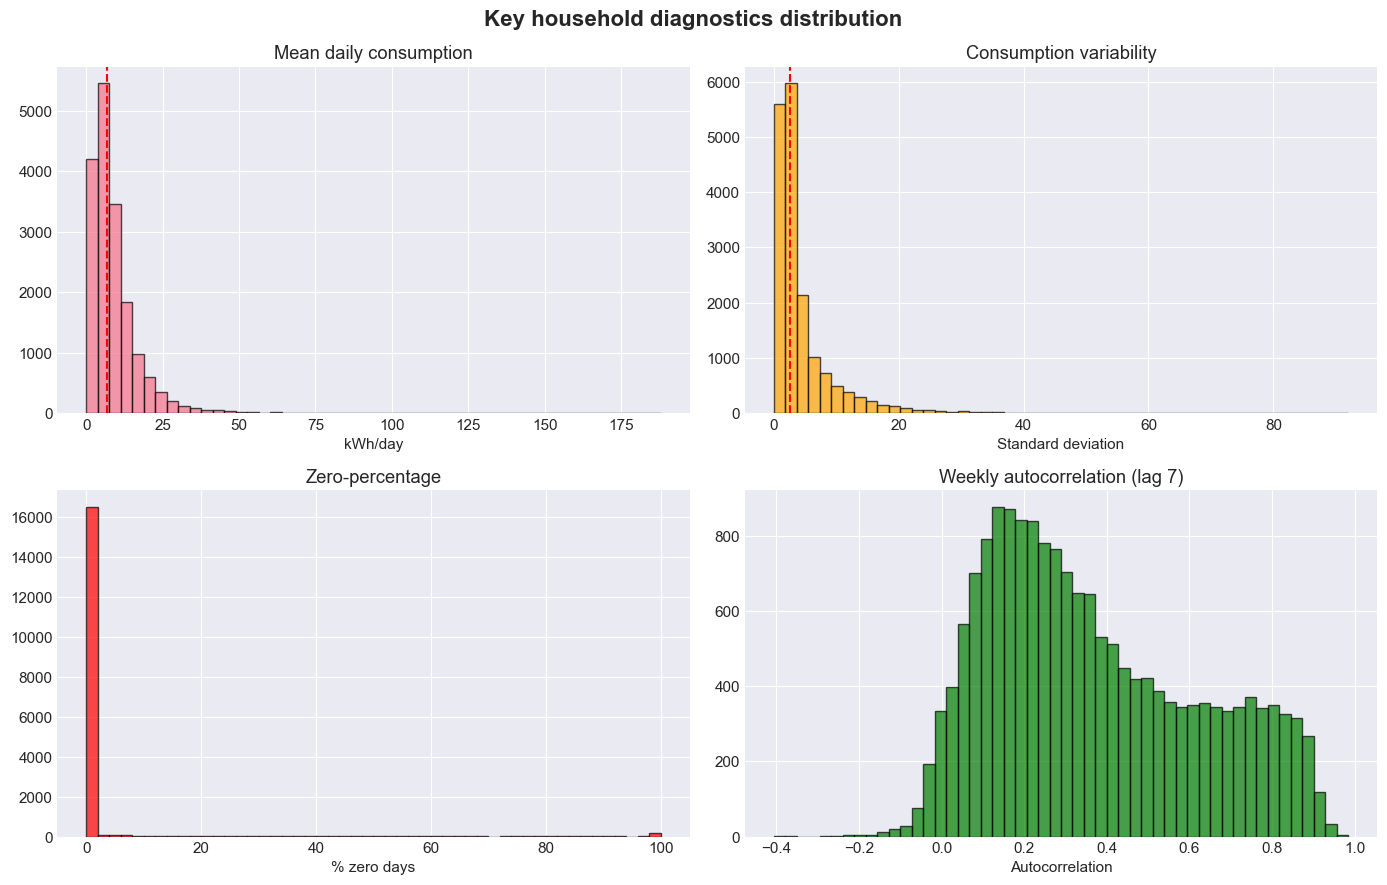

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Key household diagnostics distribution", fontsize=16, fontweight="bold")

axes[0, 0].hist(household_stats["mean"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].axvline(household_stats["mean"].median(), color="red", linestyle="--")
axes[0, 0].set_title("Mean daily consumption")
axes[0, 0].set_xlabel("kWh/day")

axes[0, 1].hist(household_stats["std"], bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[0, 1].axvline(household_stats["std"].median(), color="red", linestyle="--")
axes[0, 1].set_title("Consumption variability")
axes[0, 1].set_xlabel("Standard deviation")

axes[1, 0].hist(household_stats["zero_pct"], bins=50, edgecolor="black", alpha=0.7, color="red")
axes[1, 0].set_title("Zero-percentage")
axes[1, 0].set_xlabel("% zero days")
axes[1, 0].legend()

axes[1, 1].hist(diagnostics["autocorr_lag_7"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="green")
axes[1, 1].set_title("Weekly autocorrelation (lag 7)")
axes[1, 1].set_xlabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [7]:
from src.preprocessing.eda_analysis import split_households_for_clustering

main_ids, special_ids = split_households_for_clustering(train_data)

print(f"Main-clustering households: {len(main_ids):,}")
print(f"Special-regime households: {len(special_ids):,}")
print(f"Special-regime share: {len(special_ids) / len(diagnostics) * 100:.2f}%")

Main-clustering households: 17,224
Special-regime households: 323
Special-regime share: 1.84%


In [8]:
from src.preprocessing.eda_analysis import detect_outlier_households

# Identify outlier households
print("\n" + "="*80)
print("OUTLIER DETECTION")
print("="*80)

high_outliers_iqr, low_outliers_iqr = detect_outlier_households(household_stats, method='iqr', threshold=1.5)
high_outliers_z, low_outliers_z = detect_outlier_households(household_stats, method='zscore', threshold=3.0)

print(f"\nIQR Method (threshold=1.5):")
print(f"  High consumption outliers: {len(high_outliers_iqr)} households")
print(f"  Low consumption outliers: {len(low_outliers_iqr)} households")

print(f"\nZ-Score Method (threshold=3.0):")
print(f"  High consumption outliers: {len(high_outliers_z)} households")
print(f"  Low consumption outliers: {len(low_outliers_z)} households")

# Show examples of extreme households
print(f"\n📊 Top 5 Highest Consumers:")
top5 = household_stats.nlargest(5, 'mean')[['mean', 'std', 'min', 'max', 'cv']]
print(top5)

print(f"\n📊 Top 5 Lowest Consumers:")
bottom5 = household_stats.nsmallest(5, 'mean')[['mean', 'std', 'min', 'max', 'cv']]
print(bottom5)


OUTLIER DETECTION

IQR Method (threshold=1.5):
  High consumption outliers: 1012 households
  Low consumption outliers: 0 households

Z-Score Method (threshold=3.0):
  High consumption outliers: 272 households
  Low consumption outliers: 0 households

📊 Top 5 Highest Consumers:
              mean        std     min      max        cv
ID                                                      
82563   188.015227  53.571065  29.477  324.600  0.284929
136125  169.473123  38.044742   8.809  284.537  0.224488
167582  164.366762  45.493349  80.826  426.920  0.276779
142918  163.811504  35.324426  82.545  261.184  0.215641
121886  159.144077  37.519276  11.883  255.783  0.235757

📊 Top 5 Lowest Consumers:
       mean  std  min  max  cv
ID                            
7190    0.0  0.0  0.0  0.0 NaN
7433    0.0  0.0  0.0  0.0 NaN
8410    0.0  0.0  0.0  0.0 NaN
14237   0.0  0.0  0.0  0.0 NaN
14618   0.0  0.0  0.0  0.0 NaN


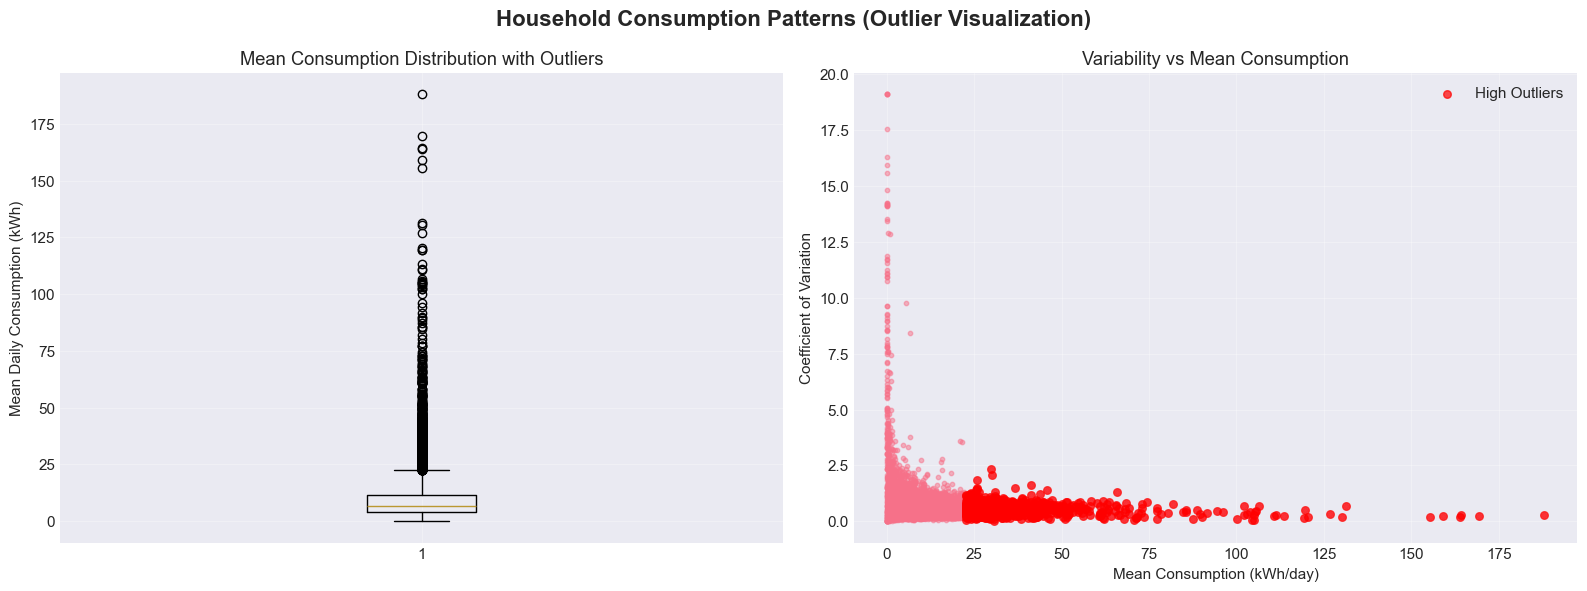

In [9]:
# Box plots for consumption patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Household Consumption Patterns (Outlier Visualization)', fontsize=16, fontweight='bold')

# Box plot of mean consumption
axes[0].boxplot(household_stats['mean'], vert=True)
axes[0].set_ylabel('Mean Daily Consumption (kWh)')
axes[0].set_title('Mean Consumption Distribution with Outliers')
axes[0].grid(True, alpha=0.3)

# Scatter plot: Mean vs CV
axes[1].scatter(household_stats['mean'], household_stats['cv'], alpha=0.5, s=10)
axes[1].set_xlabel('Mean Consumption (kWh/day)')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].set_title('Variability vs Mean Consumption')
axes[1].grid(True, alpha=0.3)

# Highlight outliers
if high_outliers_iqr:
    high_data = household_stats.loc[high_outliers_iqr]
    axes[1].scatter(high_data['mean'], high_data['cv'], color='red', s=30, alpha=0.7, label='High Outliers')

if low_outliers_iqr:
    low_data = household_stats.loc[low_outliers_iqr]
    axes[1].scatter(low_data['mean'], low_data['cv'], color='blue', s=30, alpha=0.7, label='Low Outliers')

axes[1].legend()

plt.tight_layout()
plt.show()

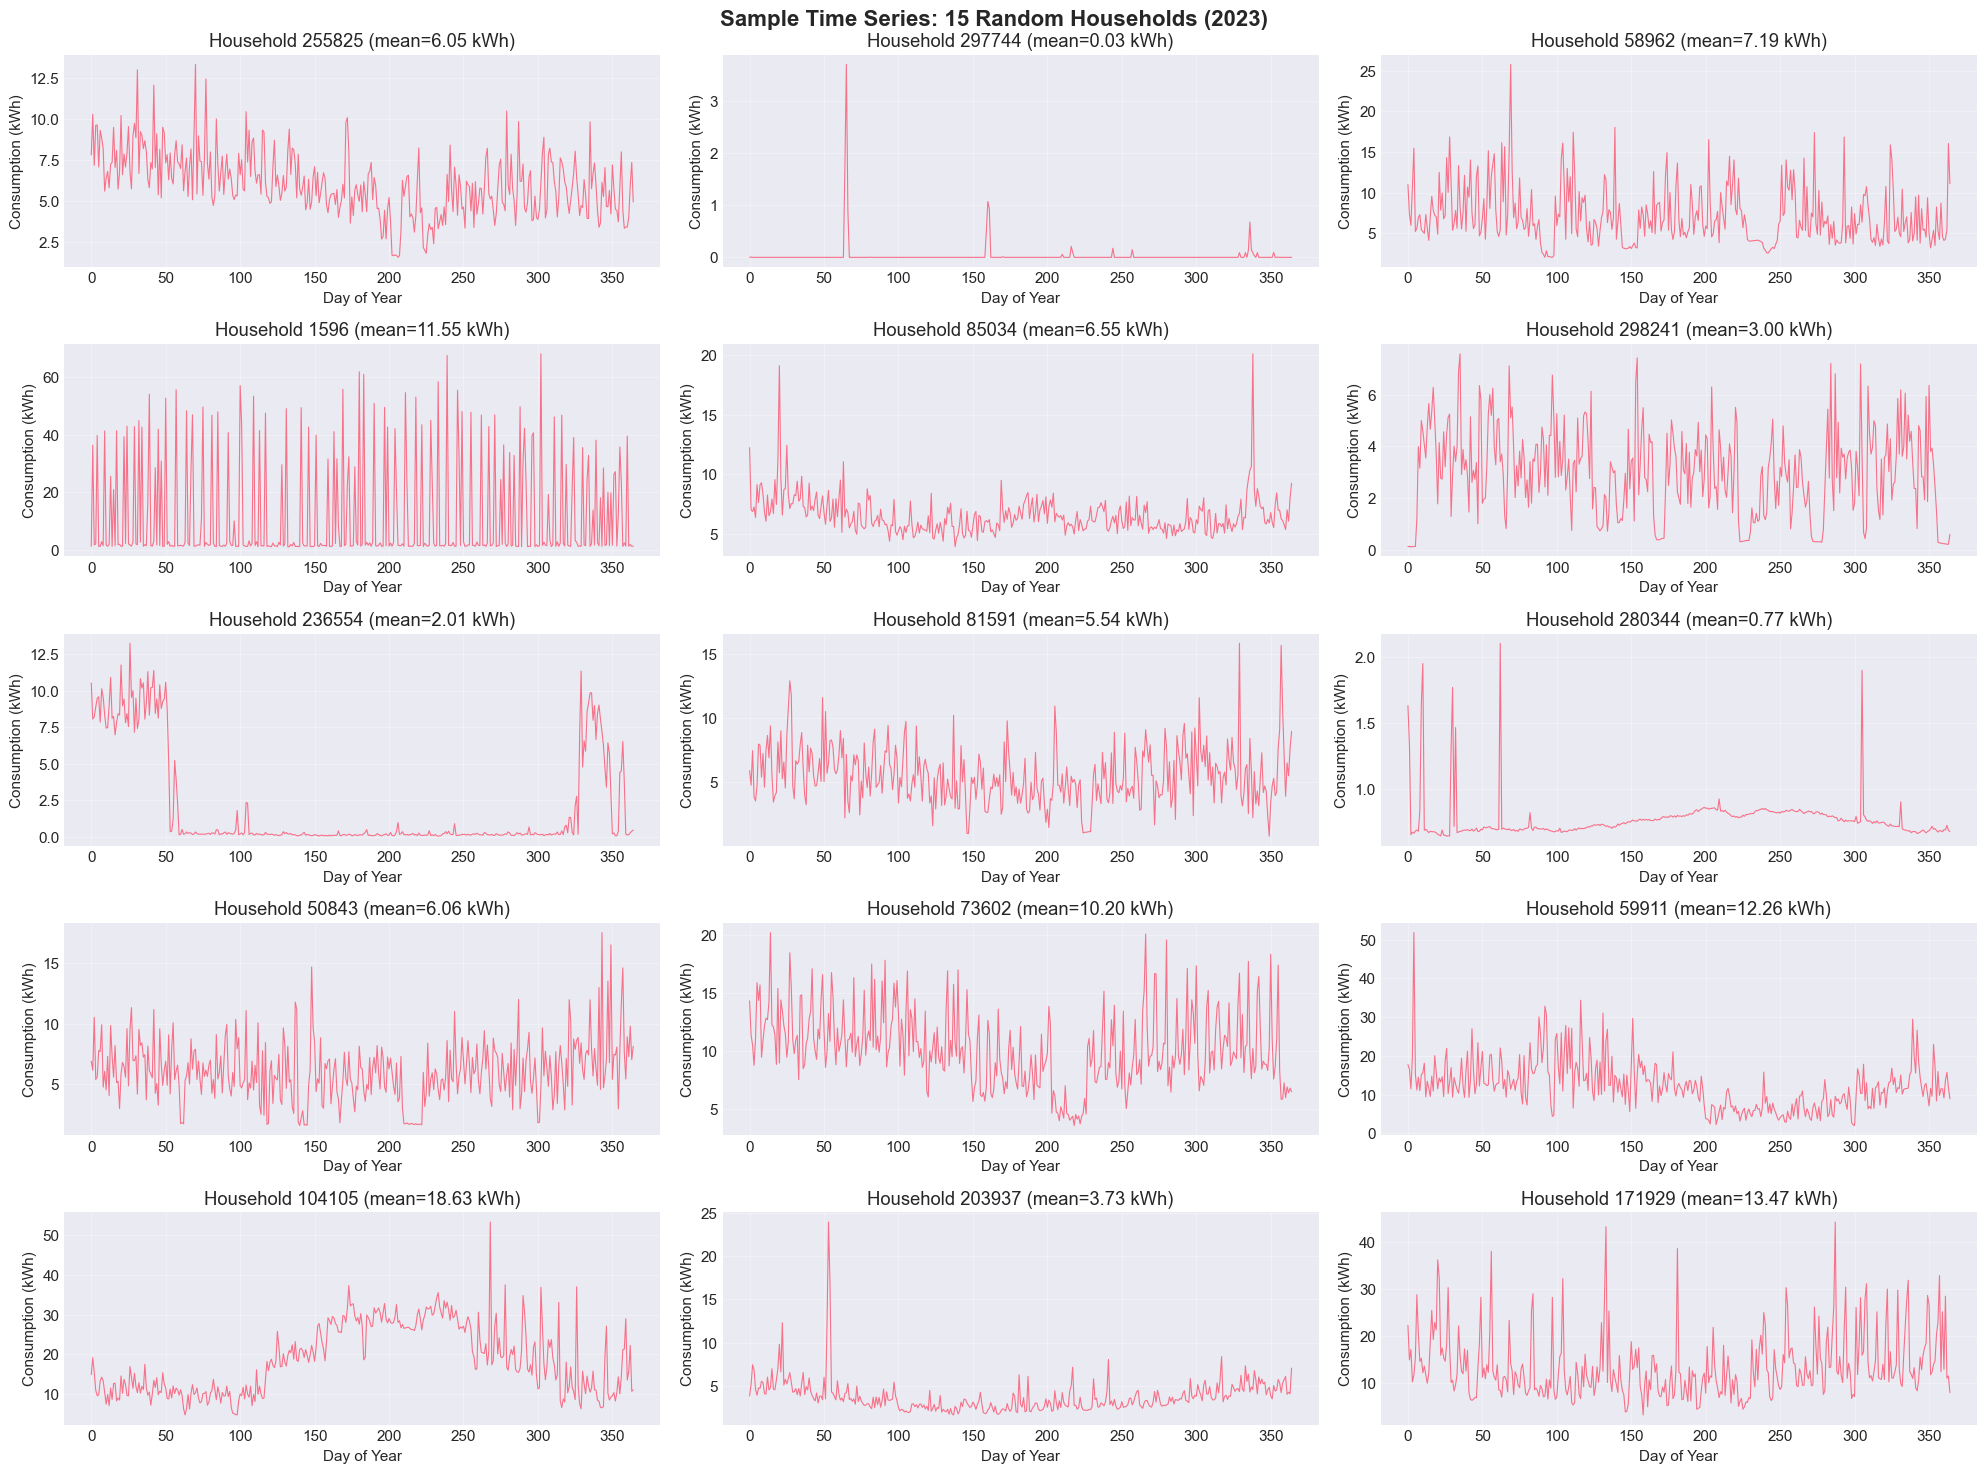

In [10]:
# Plot sample time series (10-20 random households)
sample_households = np.random.choice(train_data.index, size=15, replace=False)

fig, axes = plt.subplots(5, 3, figsize=(20, 15))
fig.suptitle('Sample Time Series: 15 Random Households (2023)', fontsize=16, fontweight='bold')

for idx, hh_id in enumerate(sample_households):
    row = idx // 3
    col = idx % 3
    
    series = train_data.loc[hh_id]
    axes[row, col].plot(series.values, linewidth=0.8)
    axes[row, col].set_title(f'Household {hh_id} (mean={household_stats.loc[hh_id, "mean"]:.2f} kWh)')
    axes[row, col].set_xlabel('Day of Year')
    axes[row, col].set_ylabel('Consumption (kWh)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


DAY-OF-WEEK ANALYSIS

Average Consumption by Day of Week:
Mon    9.072208
Tue    9.028976
Wed    9.028299
Thu    8.955290
Fri    9.079372
Sat    9.250081
Sun    9.496093
dtype: float64


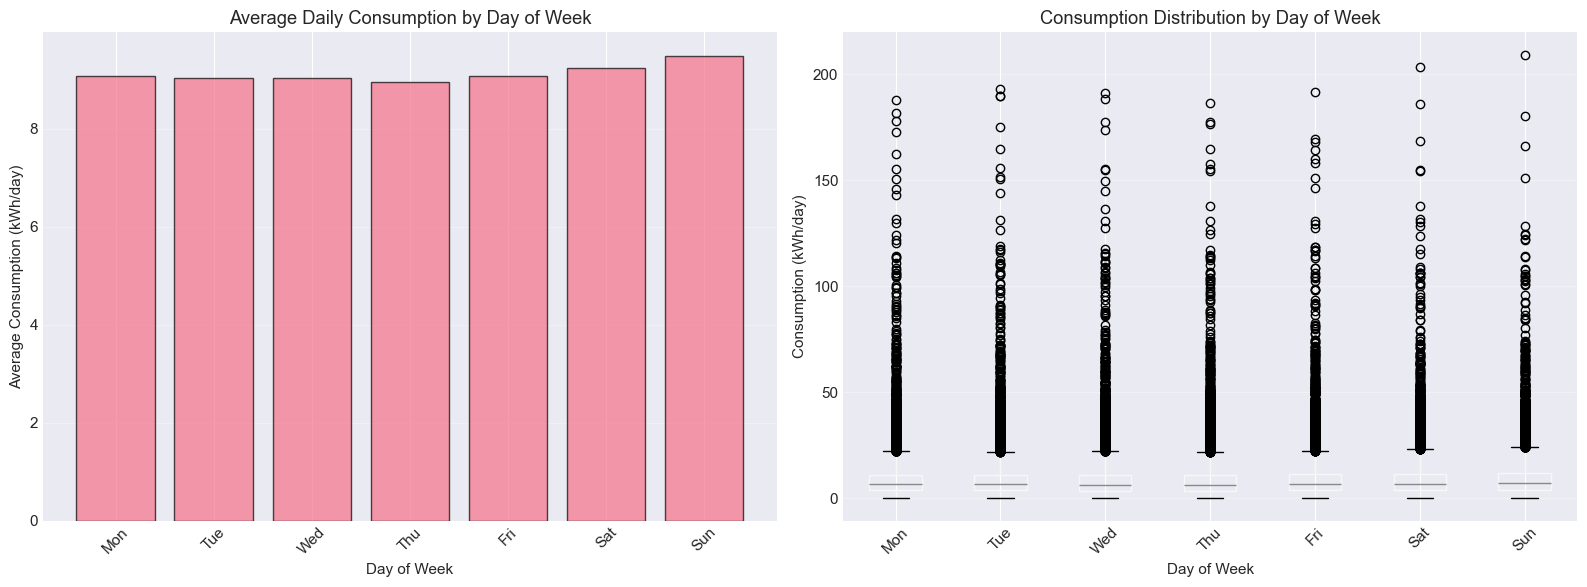

In [11]:
from src.preprocessing.eda_analysis import aggregate_by_day_of_week

# Aggregate consumption by day of week
print("\n" + "="*80)
print("DAY-OF-WEEK ANALYSIS")
print("="*80)

dow_data = aggregate_by_day_of_week(train_data)

# Average consumption by day of week (across all households)
dow_mean = dow_data.mean(axis=0)
print("\nAverage Consumption by Day of Week:")
print(dow_mean)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
x_pos = np.arange(len(dow_mean))
axes[0].bar(x_pos, dow_mean.values, edgecolor='black', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dow_mean.index, rotation=45)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Consumption (kWh/day)')
axes[0].set_title('Average Daily Consumption by Day of Week')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Box plot (distribution across households)
dow_data.boxplot(ax=axes[1])
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Consumption (kWh/day)')
axes[1].set_title('Consumption Distribution by Day of Week')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


WEEKDAY vs WEEKEND PATTERNS
Average weekday consumption: 9.03 kWh
Average weekend consumption: 9.37 kWh
Aggregate weekend/weekday ratio: 1.038
Median household weekend/weekday ratio: 1.044
Average weekend/weekday contrast: 0.023


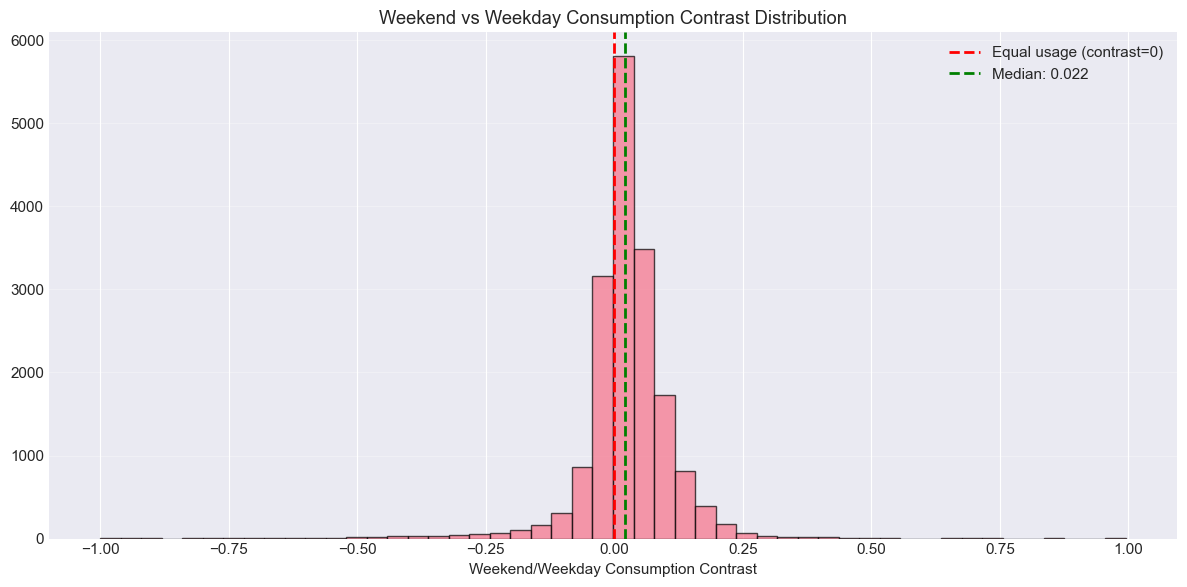

In [12]:
# Weekday vs Weekend comparison
weekday_cols = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
weekend_cols = ['Sat', 'Sun']

household_stats['weekday_mean'] = dow_data[weekday_cols].mean(axis=1)
household_stats['weekend_mean'] = dow_data[weekend_cols].mean(axis=1)

# Keep ratio only for optional reference, but do not use its mean as the main summary
household_stats['weekend_ratio'] = household_stats['weekend_mean'] / (household_stats['weekday_mean'] + 1e-10)

# Bounded contrast is more stable for household-level summaries
household_stats['weekend_weekday_contrast'] = (
    (household_stats['weekend_mean'] - household_stats['weekday_mean']) /
    (household_stats['weekend_mean'] + household_stats['weekday_mean'] + 1e-6)
)

aggregate_weekend_weekday_ratio = (
    household_stats['weekend_mean'].mean() /
    (household_stats['weekday_mean'].mean() + 1e-10)
)

print("\n" + "="*80)
print("WEEKDAY vs WEEKEND PATTERNS")
print("="*80)
print(f"Average weekday consumption: {household_stats['weekday_mean'].mean():.2f} kWh")
print(f"Average weekend consumption: {household_stats['weekend_mean'].mean():.2f} kWh")
print(f"Aggregate weekend/weekday ratio: {aggregate_weekend_weekday_ratio:.3f}")
print(f"Median household weekend/weekday ratio: {household_stats['weekend_ratio'].median():.3f}")
print(f"Average weekend/weekday contrast: {household_stats['weekend_weekday_contrast'].mean():.3f}")

# Visualize weekend ratio distribution
plt.figure(figsize=(12, 6))
plt.hist(household_stats['weekend_weekday_contrast'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0.0, color='red', linestyle='--', linewidth=2, label='Equal usage (contrast=0)')
plt.axvline(household_stats['weekend_weekday_contrast'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: {household_stats["weekend_weekday_contrast"].median():.3f}')
plt.xlabel('Weekend/Weekday Consumption Contrast')
plt.title('Weekend vs Weekday Consumption Contrast Distribution')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


MONTHLY ANALYSIS

Average Consumption by Month:
Jan    11.676373
Feb    11.352003
Mar     9.777696
Apr     9.309604
May     7.831464
Jun     7.207431
Jul     7.223234
Aug     7.381470
Sep     7.148878
Oct     8.085387
Nov    10.472680
Dec    12.244337
dtype: float64


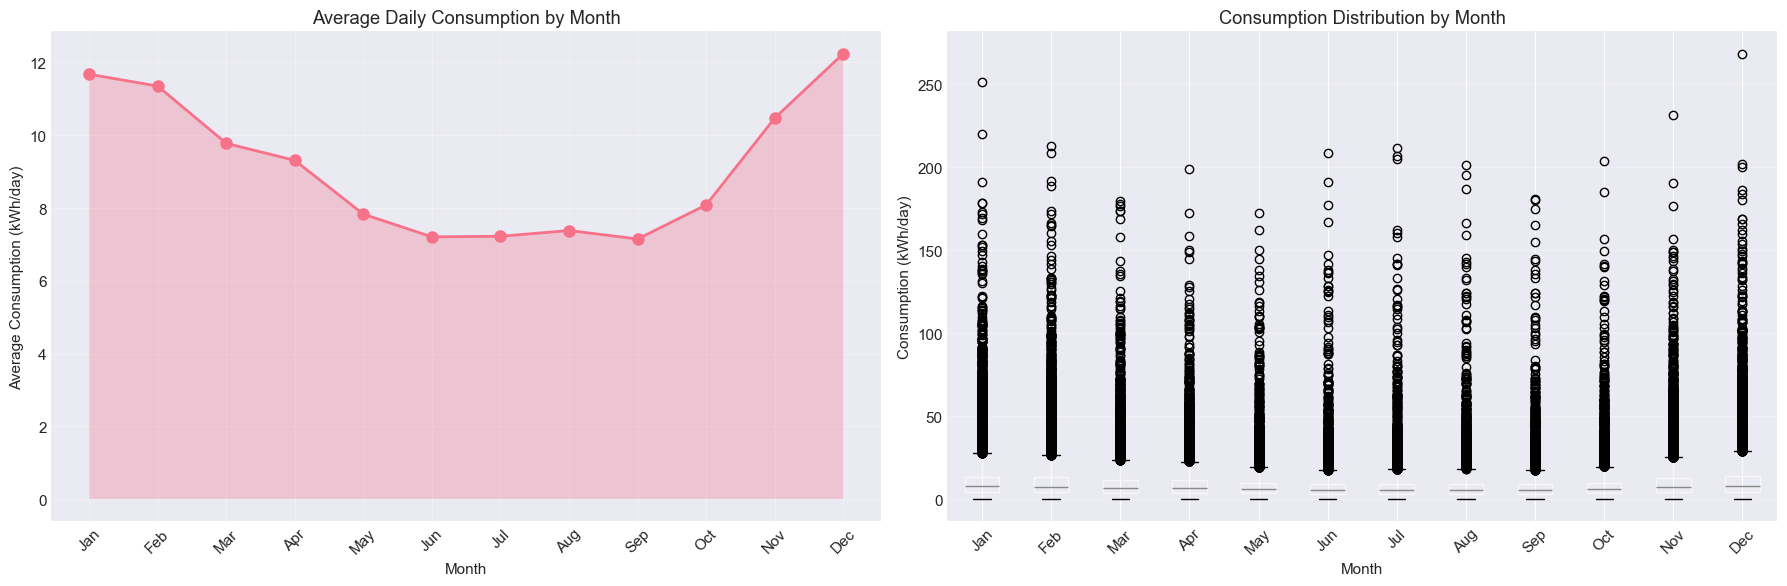

In [13]:
from src.preprocessing.eda_analysis import aggregate_by_month

# Aggregate consumption by month
print("\n" + "="*80)
print("MONTHLY ANALYSIS")
print("="*80)

monthly_data = aggregate_by_month(train_data)

# Average consumption by month (across all households)
monthly_mean = monthly_data.mean(axis=0)
print("\nAverage Consumption by Month:")
print(monthly_mean)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Line plot
x_pos = np.arange(len(monthly_mean))
axes[0].plot(x_pos, monthly_mean.values, marker='o', linewidth=2, markersize=8)
axes[0].fill_between(x_pos, monthly_mean.values, alpha=0.3)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(monthly_mean.index, rotation=45)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Consumption (kWh/day)')
axes[0].set_title('Average Daily Consumption by Month')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Box plot
monthly_data.boxplot(ax=axes[1])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Consumption (kWh/day)')
axes[1].set_title('Consumption Distribution by Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


SEASONAL PATTERNS (Winter vs Summer)
Average winter consumption: 11.76 kWh
Average summer consumption: 7.27 kWh
Average winter/summer contrast: 0.165

Seasonal Pattern Categories:
  Winter-dominant (>0.10): 9248 households (52.7%)
  Balanced (-0.10 to 0.10): 6647 households (37.9%)
  Summer-dominant (<-0.10): 1652 households (9.4%)


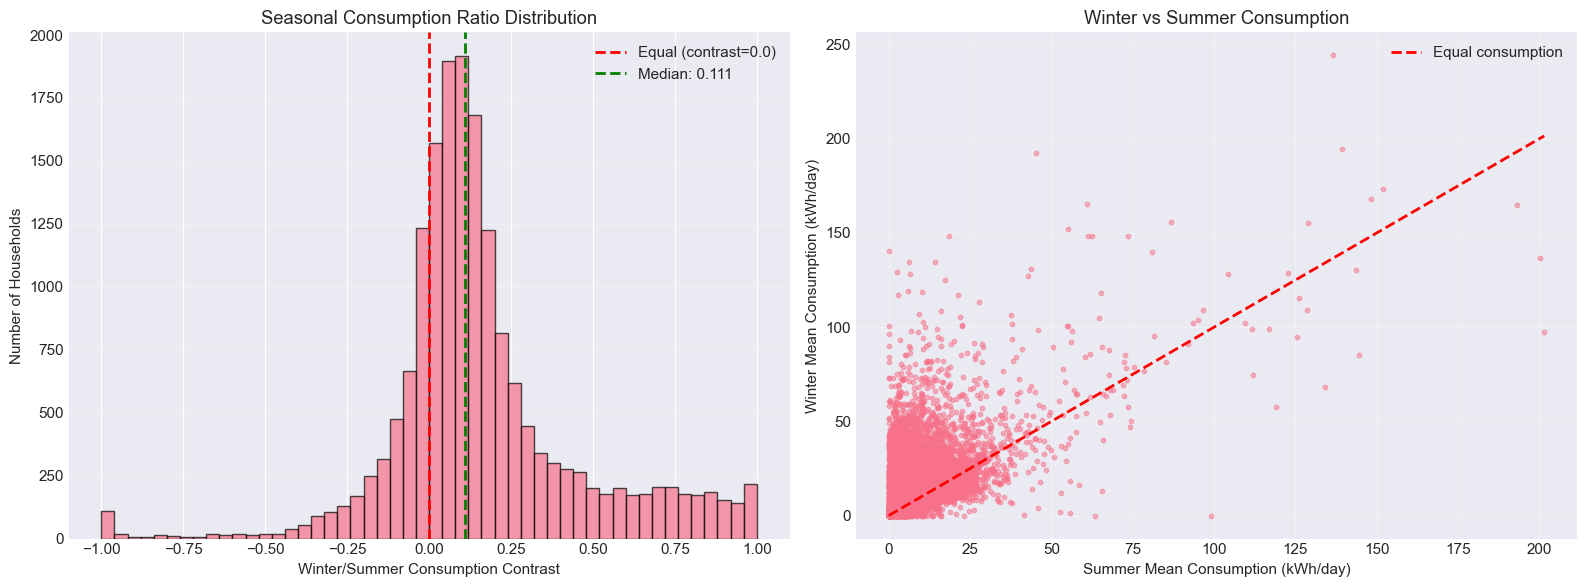

In [14]:
# Seasonal analysis (Winter vs Summer)
winter_months = ['Jan', 'Feb', 'Dec']
summer_months = ['Jun', 'Jul', 'Aug']

# Filter months that exist in our data
winter_cols = [m for m in winter_months if m in monthly_data.columns]
summer_cols = [m for m in summer_months if m in monthly_data.columns]

household_stats['winter_mean'] = monthly_data[winter_cols].mean(axis=1)
household_stats['summer_mean'] = monthly_data[summer_cols].mean(axis=1)
household_stats['winter_summer_contrast'] = (
    (household_stats['winter_mean'] - household_stats['summer_mean']) /
    (household_stats['winter_mean'] + household_stats['summer_mean'] + 1e-6)
)

print("\n" + "="*80)
print("SEASONAL PATTERNS (Winter vs Summer)")
print("="*80)
print(f"Average winter consumption: {household_stats['winter_mean'].mean():.2f} kWh")
print(f"Average summer consumption: {household_stats['summer_mean'].mean():.2f} kWh")
print(f"Average winter/summer contrast: {household_stats['winter_summer_contrast'].mean():.3f}")

seasonal_categories = {
    'Winter-dominant (>0.10)': len(household_stats[household_stats['winter_summer_contrast'] > 0.10]),
    'Balanced (-0.10 to 0.10)': len(household_stats[
        (household_stats['winter_summer_contrast'] >= -0.10) &
        (household_stats['winter_summer_contrast'] <= 0.10)
    ]),
    'Summer-dominant (<-0.10)': len(household_stats[household_stats['winter_summer_contrast'] < -0.10]),
}

print("\nSeasonal Pattern Categories:")
for category, count in seasonal_categories.items():
    print(f"  {category}: {count} households ({count/len(household_stats)*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of winter/summer contrast
axes[0].hist(household_stats['winter_summer_contrast'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0.0, color='red', linestyle='--', linewidth=2, label='Equal (contrast=0.0)')
axes[0].axvline(household_stats['winter_summer_contrast'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {household_stats["winter_summer_contrast"].median():.3f}')
axes[0].set_xlabel('Winter/Summer Consumption Contrast')
axes[0].set_ylabel('Number of Households')
axes[0].set_title('Seasonal Consumption Ratio Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot: Winter vs Summer
axes[1].scatter(household_stats['summer_mean'], household_stats['winter_mean'], alpha=0.5, s=10)
axes[1].plot([0, household_stats['summer_mean'].max()], [0, household_stats['summer_mean'].max()], 
             'r--', linewidth=2, label='Equal consumption')
axes[1].set_xlabel('Summer Mean Consumption (kWh/day)')
axes[1].set_ylabel('Winter Mean Consumption (kWh/day)')
axes[1].set_title('Winter vs Summer Consumption')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

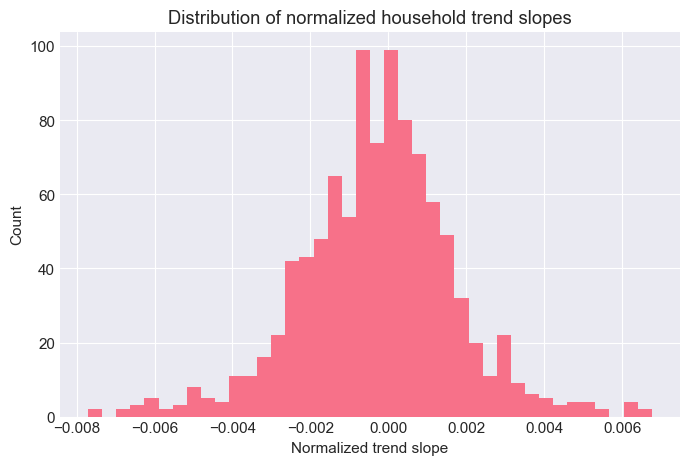

In [15]:
from src.preprocessing.eda_analysis import detect_normalized_trend

trend_ids = np.random.choice(train_data.index, size=min(1000, len(train_data)), replace=False)
norm_slopes = [detect_normalized_trend(train_data, hh)["trend_slope_normalized"] for hh in trend_ids]

plt.figure(figsize=(8, 5))
plt.hist(norm_slopes, bins=40)
plt.title("Distribution of normalized household trend slopes")
plt.xlabel("Normalized trend slope")
plt.ylabel("Count")
plt.show()

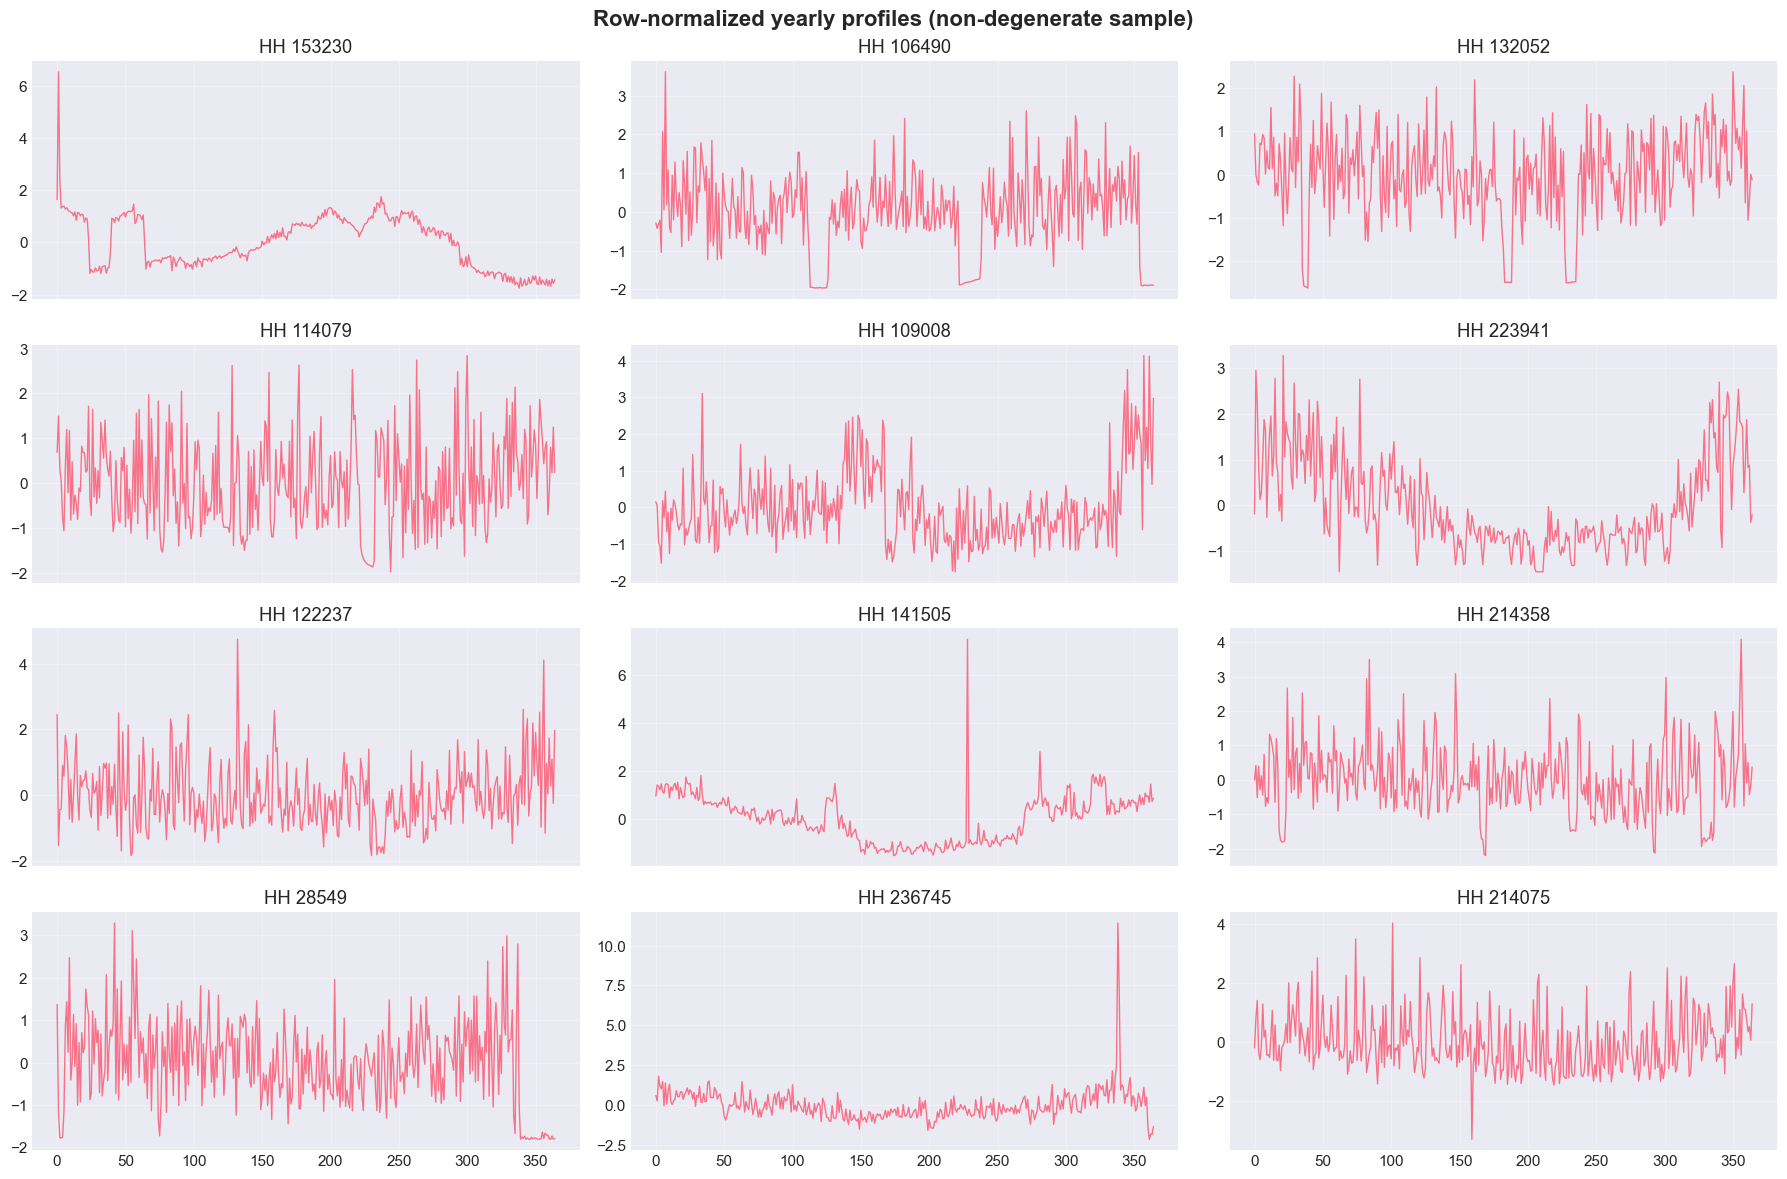

In [16]:
from src.preprocessing.eda_analysis import z_normalize_rows

normalized_data = z_normalize_rows(train_data)
sample_ids = np.random.choice(main_ids, size=12, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True)
fig.suptitle("Row-normalized yearly profiles (non-degenerate sample)", fontsize=16, fontweight="bold")

for ax, hh_id in zip(axes.ravel(), sample_ids):
    ax.plot(normalized_data.loc[hh_id].values, linewidth=1.0)
    ax.set_title(f"HH {hh_id}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Initial Clustering Insights


In [17]:
print("\n" + "="*80)
print("CLUSTERING-RELEVANT STRUCTURE")
print("="*80)

print("Weekly autocorrelation summary:")
display(diagnostics["autocorr_lag_7"].describe())

print("\nMonthly profile variability summary:")
display(diagnostics["monthly_profile_std"].describe())


CLUSTERING-RELEVANT STRUCTURE
Weekly autocorrelation summary:


count    17392.000000
mean         0.365436
std          0.254231
min         -0.406425
25%          0.160171
50%          0.312375
75%          0.555809
max          0.984751
Name: autocorr_lag_7, dtype: float64


Monthly profile variability summary:


count    17547.000000
mean         3.045500
std          4.934552
min          0.000000
25%          0.597858
50%          1.223707
75%          3.004465
max         69.048264
Name: monthly_profile_std, dtype: float64

In [18]:
from src.preprocessing.eda_analysis import categorize_households

# Categorize households based on consumption patterns
household_categories = categorize_households(household_stats)

print("\n" + "="*80)
print("PRELIMINARY CONSUMPTION GROUPS")
print("="*80)
print("\nCategory Distribution:")
print(household_categories.value_counts())
print("\nPercentages:")
print((household_categories.value_counts() / len(household_categories) * 100).round(2))

# Add categories to stats DataFrame
household_stats['category'] = household_categories


PRELIMINARY CONSUMPTION GROUPS

Category Distribution:
Medium Stable          5073
High Stable            3991
Low Stable             3981
High Variable          1798
Low Variable           1534
Medium Variable         891
Unclassified            154
Intermittent/Vacant     125
Name: count, dtype: Int64

Percentages:
Medium Stable          28.91
High Stable            22.74
Low Stable             22.69
High Variable          10.25
Low Variable            8.74
Medium Variable         5.08
Unclassified            0.88
Intermittent/Vacant     0.71
Name: count, dtype: Float64


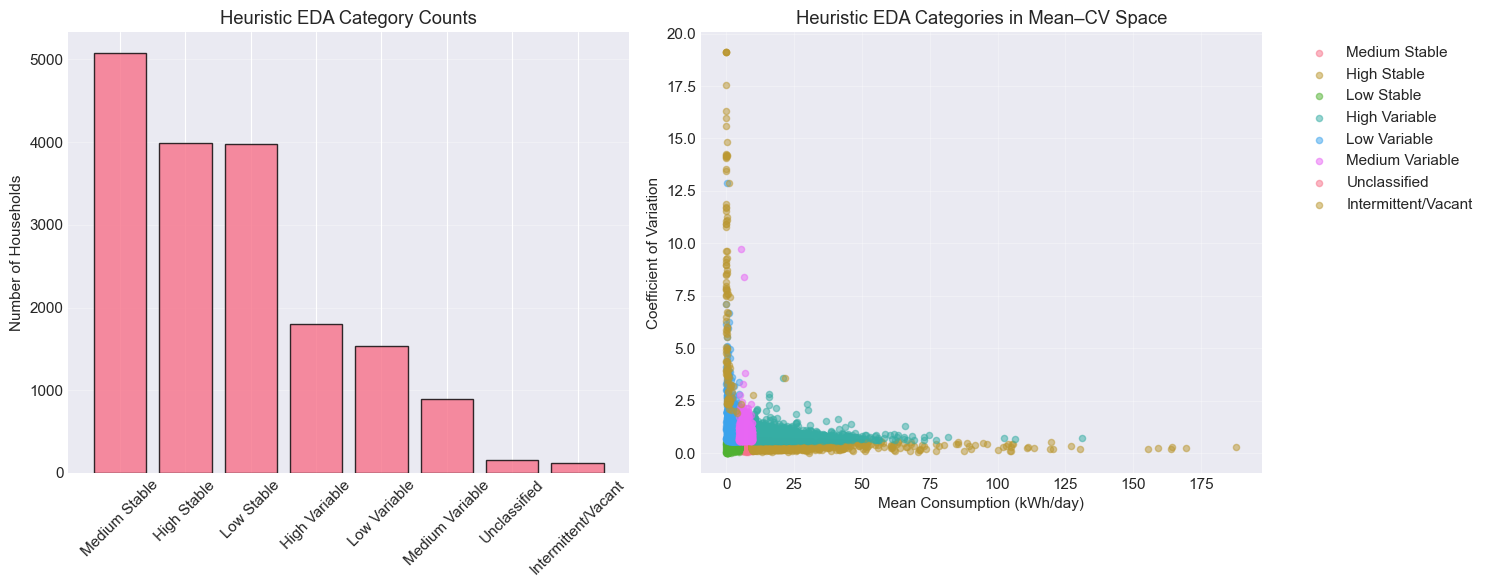

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

category_counts = household_categories.value_counts()

# 1. Category counts
axes[0].bar(category_counts.index, category_counts.values, edgecolor='black', alpha=0.8)
axes[0].set_title('Heuristic EDA Category Counts')
axes[0].set_ylabel('Number of Households')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Mean vs CV by category
for cat in category_counts.index:
    cat_data = household_stats[household_stats['category'] == cat]
    axes[1].scatter(cat_data['mean'], cat_data['cv'], label=cat, alpha=0.5, s=20)

axes[1].set_xlabel('Mean Consumption (kWh/day)')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].set_title('Heuristic EDA Categories in Mean–CV Space')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Summary & Key Insights

In [20]:
print("\n" + "="*80)
print("EDA SUMMARY & KEY INSIGHTS")
print("="*80)

print(f"\nTotal households: {len(train_data):,}")
print(f"Special-regime households: {len(special_ids):,} ({len(special_ids)/len(train_data)*100:.2f}%)")

print("\nKey clustering-relevant findings:")
print(f"  • Weekly autocorrelation median: {diagnostics['autocorr_lag_7'].median():.3f}")
print(f"  • Monthly profile variability median: {diagnostics['monthly_profile_std'].median():.3f}")
print(f"  • Winter/summer contrast mean: {household_stats['winter_summer_contrast'].mean():.3f}")

print("\nInterpretation:")
print("  • A nontrivial subset of households shows special-regime behavior and should not drive the main fit.")
print("  • The data contain both shape-based and seasonal structure, supporting comparison of feature-based and sequence-based methods.")
print("  • Feature-Ward is the primary scalable candidate; k-Shape and DTW-medoid are retained as benchmarks.")


EDA SUMMARY & KEY INSIGHTS

Total households: 17,547
Special-regime households: 323 (1.84%)

Key clustering-relevant findings:
  • Weekly autocorrelation median: 0.312
  • Monthly profile variability median: 1.224
  • Winter/summer contrast mean: 0.165

Interpretation:
  • A nontrivial subset of households shows special-regime behavior and should not drive the main fit.
  • The data contain both shape-based and seasonal structure, supporting comparison of feature-based and sequence-based methods.
  • Feature-Ward is the primary scalable candidate; k-Shape and DTW-medoid are retained as benchmarks.
